In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("Unemployment in India.csv")
df.head()

Saving Unemployment in India.csv to Unemployment in India (1).csv


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
df.shape

(768, 7)

In [4]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [5]:
df.dtypes

,0
Region,object
Date,object
Frequency,object
Estimated Unemployment Rate (%),float64
Estimated Employed,float64
Estimated Labour Participation Rate (%),float64
Area,object


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [7]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [8]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [9]:
df.duplicated().sum()

np.int64(27)

**DATE CLEANING:**

In [10]:
df=df.dropna()

In [11]:
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


In [12]:
df.shape

(740, 7)

In [13]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [14]:
df.columns=df.columns.str.strip()
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

***CONVERTING DATE TIME COLUMN INTO TYPE DATE TIME:***

In [15]:
df['Date']= pd.to_datetime(df['Date'])


/tmp/ipykernel_34382/3228325314.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date']= pd.to_datetime(df['Date'])


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


***AVERAGE UNEMPLOYMENT RATE***

In [17]:
df['Estimated Unemployment Rate (%)'].mean()

np.float64(11.787945945945946)

***HIGHEST UNEMPLOYMENT RATE***

In [18]:
df["Estimated Unemployment Rate (%)"].max()

76.74

***LOWEST UNEMPLOYMENT RATE***

In [19]:
df["Estimated Unemployment Rate (%)"].min()

0.0

***AVERAGE EMPLOYMENT***

In [20]:
df["Estimated Employed"].mean()

np.float64(7204460.025675676)

***AVERAGE LABOUR PARTICIPATION RATE***

In [21]:
df["Estimated Labour Participation Rate (%)"].mean()

np.float64(42.630121621621626)

In [22]:
df["Region"].nunique()

28

In [23]:
df["Region"].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Chandigarh'],
      dtype=object)

In [24]:
df["Estimated Unemployment Rate (%)"].describe()

,Estimated Unemployment Rate (%)
count,740.000000
mean,11.787946
std,10.721298
min,0.000000
25%,4.657500
50%,8.350000
75%,15.887500
max,76.740000


In [25]:
df["Area"].value_counts()

,count
Area,
Urban,381
Rural,359


In [26]:
#FINDING OUT WHICH STATE HAS HIGHEST UNEMPLOYMENT RATE
df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


In [27]:
#FINDING OUT WHICH STATE HAS LOWEST UNEMPLOYMENT RATE
df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values()

,Estimated Unemployment Rate (%)
Region,
Meghalaya,4.798889
Odisha,5.657857
Assam,6.428077
Uttarakhand,6.582963
Gujarat,6.663929
Karnataka,6.676071
Sikkim,7.249412
Madhya Pradesh,7.406429
Andhra Pradesh,7.477143


In [28]:
df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False).head(10)

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


In [29]:
df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values().head(10)

,Estimated Unemployment Rate (%)
Region,
Meghalaya,4.798889
Odisha,5.657857
Assam,6.428077
Uttarakhand,6.582963
Gujarat,6.663929
Karnataka,6.676071
Sikkim,7.249412
Madhya Pradesh,7.406429
Andhra Pradesh,7.477143




***The analysis shows that Tripura recorded the highest average unemployment rate (28.35%), followed by Haryana (26.28%). On the other hand, Meghalaya had the lowest average unemployment rate (4.79%), indicating significant variation in unemployment across different states***

/tmp/ipykernel_34382/3587462492.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


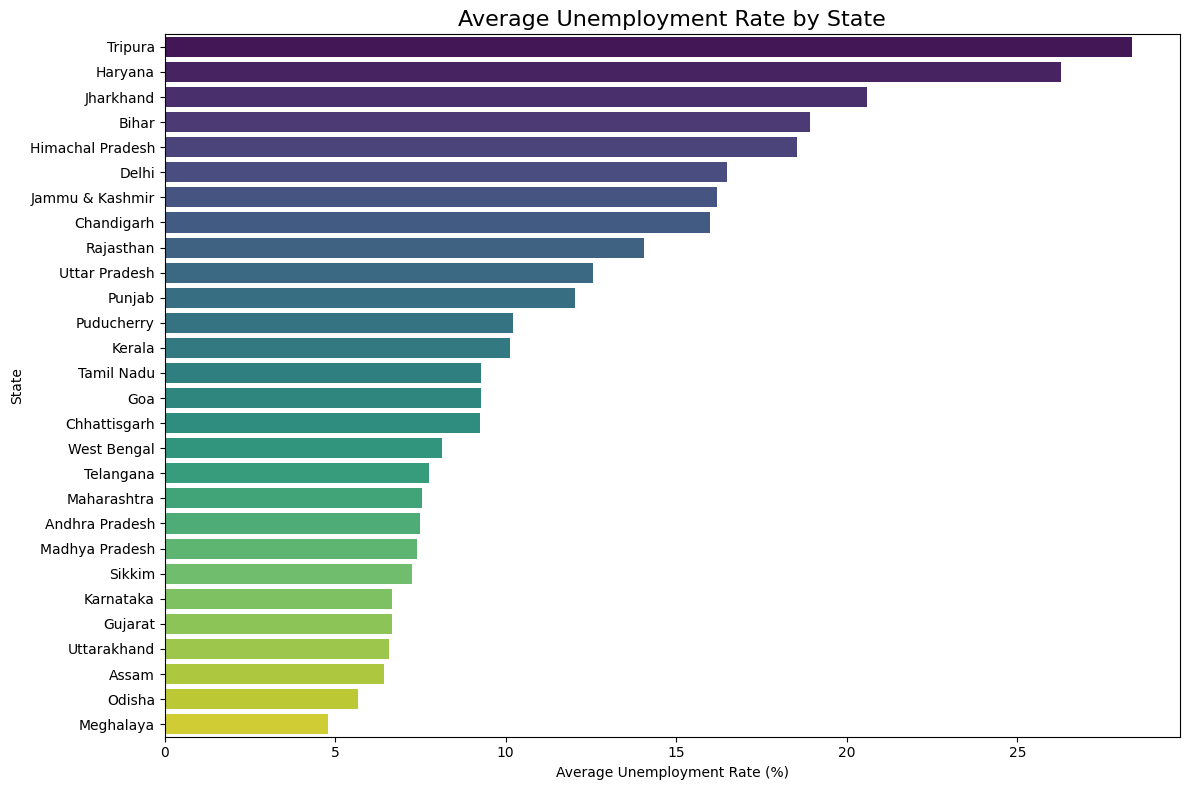

In [30]:
plt.figure(figsize=(12,8))

state_unemp = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

sns.barplot(
    x=state_unemp.values,
    y=state_unemp.index,
    palette="viridis"      # Better colors
)

plt.title("Average Unemployment Rate by State", fontsize=16)
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")

plt.tight_layout()         # Labels cut nahi honge

plt.show()

In [31]:
df.groupby("Area")["Estimated Unemployment Rate (%)"].mean()

,Estimated Unemployment Rate (%)
Area,
Rural,10.324791
Urban,13.166614


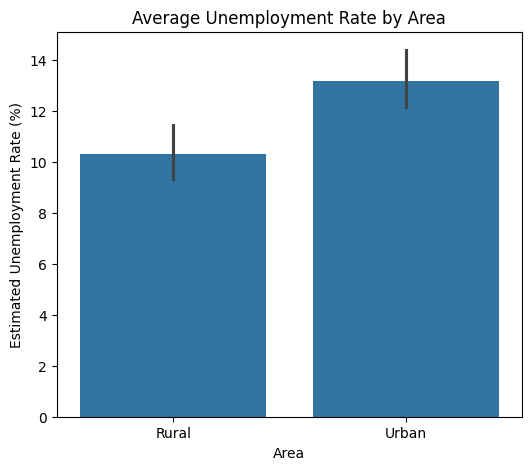

In [32]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=df,
    x="Area",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Average Unemployment Rate by Area")
plt.show()

In [33]:
df["Month"] = df["Date"].dt.month_name()

In [34]:
df[["Date","Month"]].head()

,Date,Month
0,2019-05-31,May
1,2019-06-30,June
2,2019-07-31,July
3,2019-08-31,August
4,2019-09-30,September


***MONTH WISE AVG UNEMPLOYMENT***

In [35]:
monthly_avg = df.groupby("Month")["Estimated Unemployment Rate (%)"].mean()
monthly_avg

,Estimated Unemployment Rate (%)
Month,
April,23.641569
August,9.637925
December,9.497358
February,9.964717
January,9.950755
July,9.033889
June,10.553462
March,10.700577
May,16.646190


In [36]:
order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_avg = monthly_avg.reindex(order)
monthly_avg

,Estimated Unemployment Rate (%)
Month,
January,9.950755
February,9.964717
March,10.700577
April,23.641569
May,16.646190
June,10.553462
July,9.033889
August,9.637925
September,9.051731


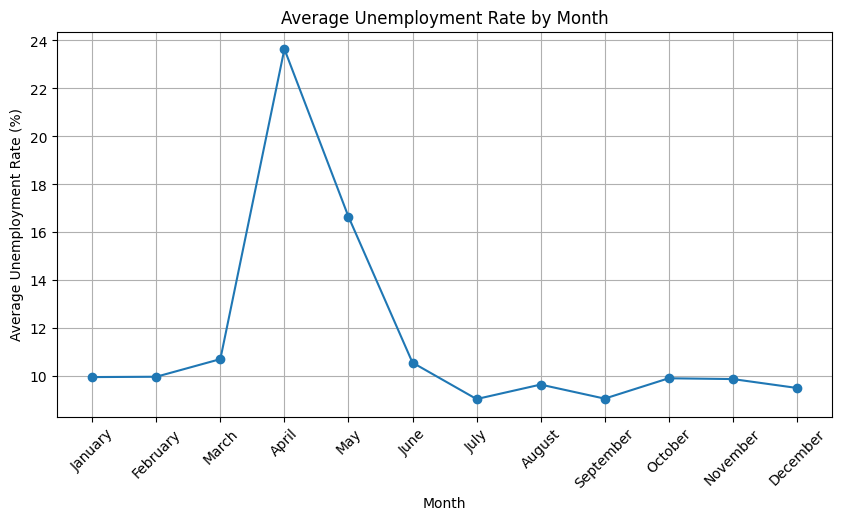

In [37]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o"
)

plt.xticks(rotation=45)
plt.title("Average Unemployment Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.grid(True)

plt.show()

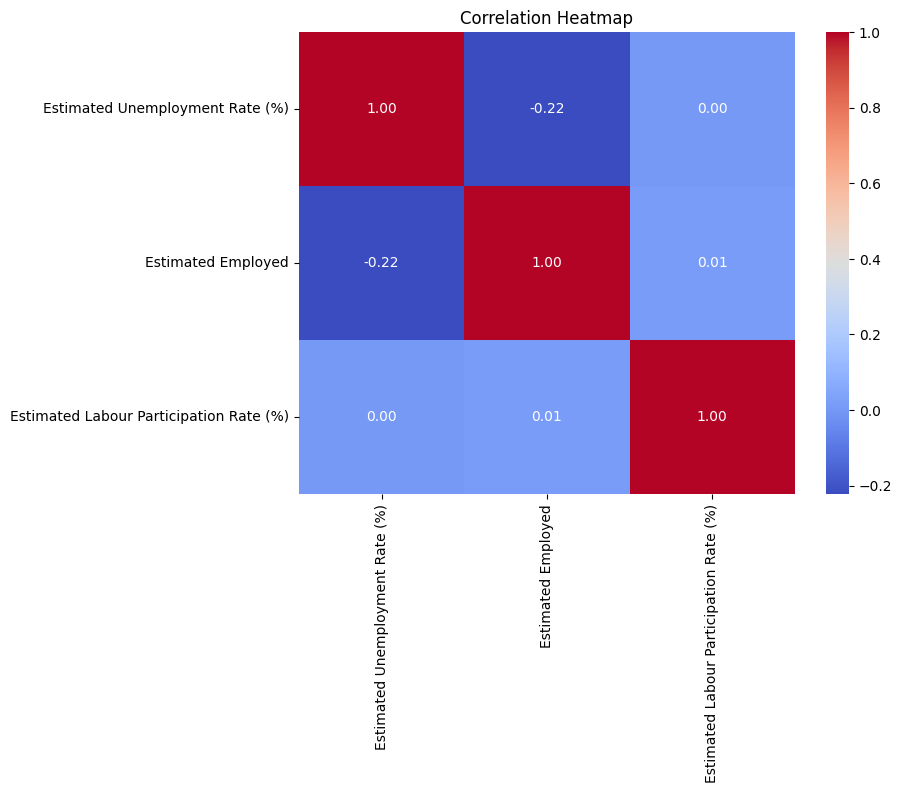

In [38]:
plt.figure(figsize=(8,6))

corr = df[[
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

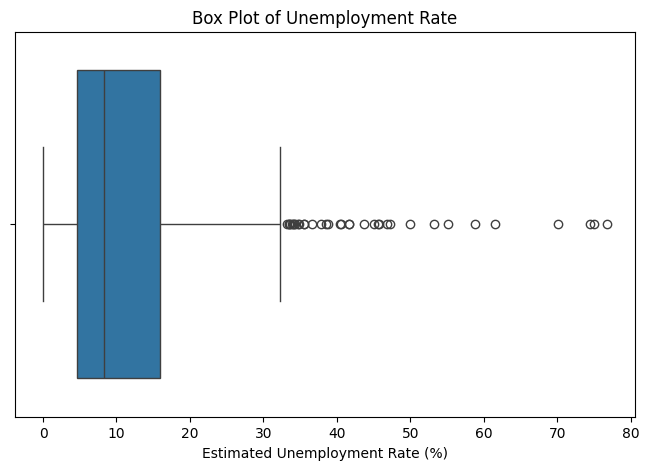

In [39]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Estimated Unemployment Rate (%)"]
)

plt.title("Box Plot of Unemployment Rate")

plt.show()

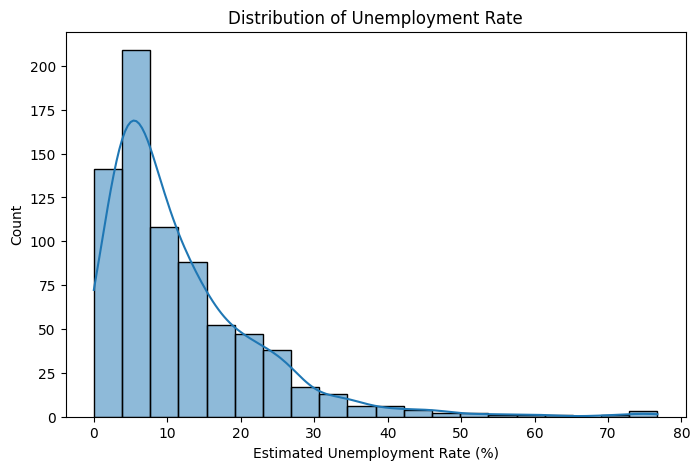

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Estimated Unemployment Rate (%)"],
    bins=20,
    kde=True
)

plt.title("Distribution of Unemployment Rate")

plt.show()

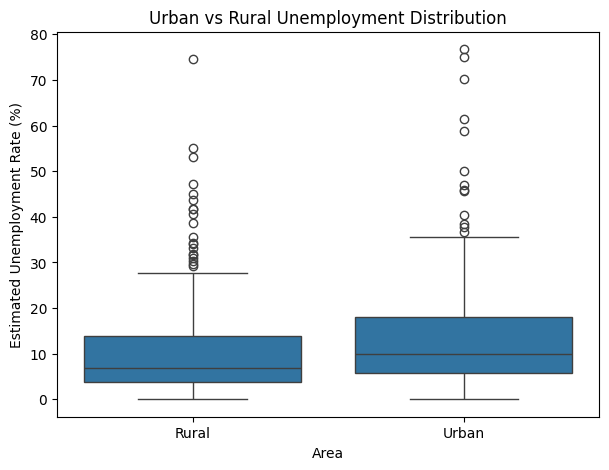

In [41]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Area",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Urban vs Rural Unemployment Distribution")

plt.show()

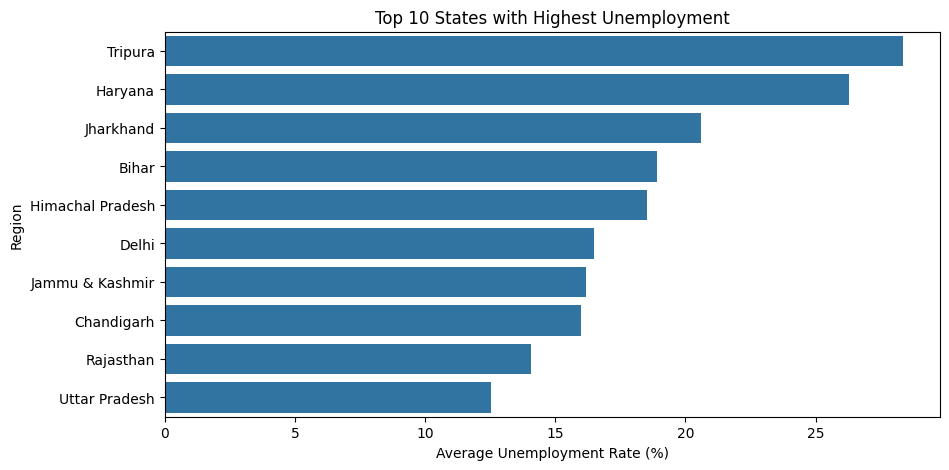

In [42]:
top10 = df.groupby("Region")["Estimated Unemployment Rate (%)"]\
          .mean()\
          .sort_values(ascending=False)\
          .head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 States with Highest Unemployment")

plt.xlabel("Average Unemployment Rate (%)")

plt.show()

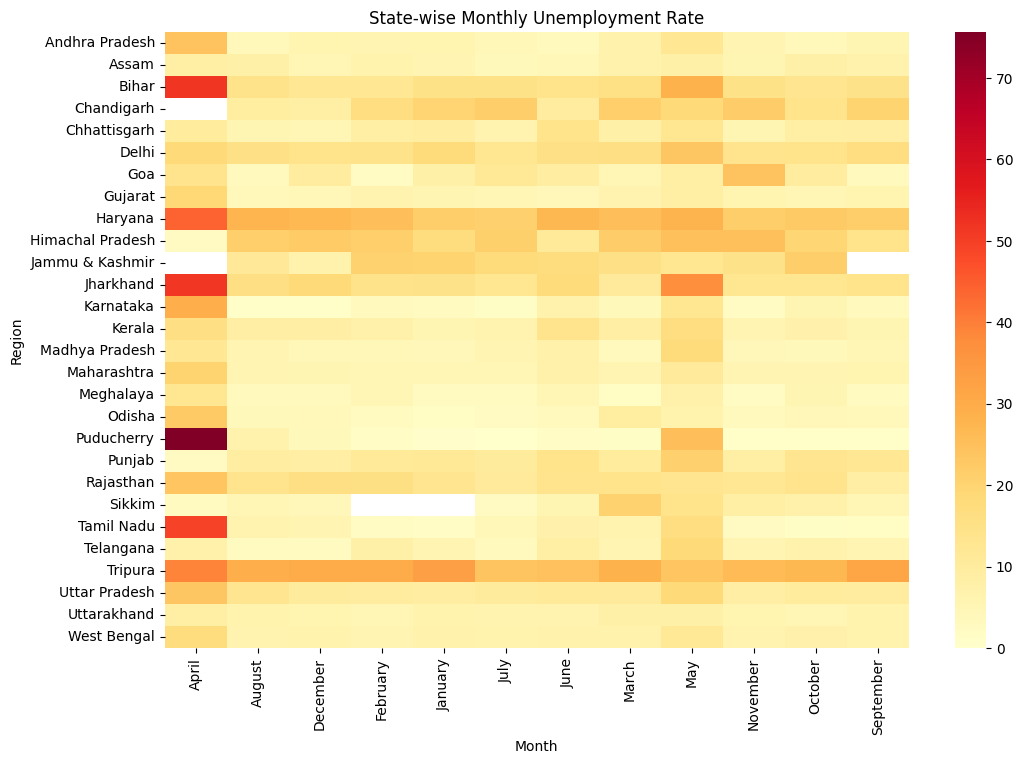

In [43]:
pivot = df.pivot_table(
    values="Estimated Unemployment Rate (%)",
    index="Region",
    columns="Month",
    aggfunc="mean"
)

plt.figure(figsize=(12,8))

sns.heatmap(
    pivot,
    cmap="YlOrRd"
)

plt.title("State-wise Monthly Unemployment Rate")
plt.show()

# ***INSIGHTS***


1.   Tripura had the highest average unemployment rate.
2.   Meghalaya had the lowest average unemployment rate.
3.   Most unemployment values were between 5% and 15%.
4.   Urban and Rural unemployment rates were relatively close.
5.   Employment and unemployment showed a weak negative correlation.
6.   Several states experienced unusually high unemployment, creating outliers.
7.   Unemployment varied across months, indicating seasonal changes.








# **CONCLUSION**
***The unemployment dataset reveals significant variation across Indian states.
Some states consistently experienced higher unemployment than others.
The overall unemployment distribution is positively skewed, with most observations below 15%.
Correlation analysis shows a weak inverse relationship between employment and unemployment.
These findings can help policymakers identify regions requiring employment-focused interventions.***

***COVID 19 IMPACT ANALYSIS:***

In [44]:
from google.colab import files
uploaded = files.upload()
covid_df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")


Saving Unemployment_Rate_upto_11_2020.csv to Unemployment_Rate_upto_11_2020 (1).csv


In [45]:
covid_df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [46]:
covid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [47]:
covid_df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')

In [48]:
covid_df.columns = covid_df.columns.str.strip()

In [49]:
covid_df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')

In [50]:
covid_df["Date"] = pd.to_datetime(covid_df["Date"])

/tmp/ipykernel_34382/832093445.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  covid_df["Date"] = pd.to_datetime(covid_df["Date"])


In [51]:
covid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   267 non-null    object        
 1   Date                                     267 non-null    datetime64[ns]
 2   Frequency                                267 non-null    object        
 3   Estimated Unemployment Rate (%)          267 non-null    float64       
 4   Estimated Employed                       267 non-null    int64         
 5   Estimated Labour Participation Rate (%)  267 non-null    float64       
 6   Region.1                                 267 non-null    object        
 7   longitude                                267 non-null    float64       
 8   latitude                                 267 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1), 

In [52]:
covid_df["Month"] = covid_df["Date"].dt.month_name()

In [53]:
#MONTHLY AVERAGE UNEMPLOYMENT:
monthly_covid = covid_df.groupby("Month")["Estimated Unemployment Rate (%)"].mean()

In [54]:
order = [
    "January","February","March","April","May",
    "June","July","August","September","October","November"
]

monthly_covid = monthly_covid.reindex(order)
monthly_covid

,Estimated Unemployment Rate (%)
Month,
January,9.196538
February,9.266154
March,10.782593
April,22.236154
May,23.244444
June,10.911111
July,9.834444
August,10.313333
September,8.705926


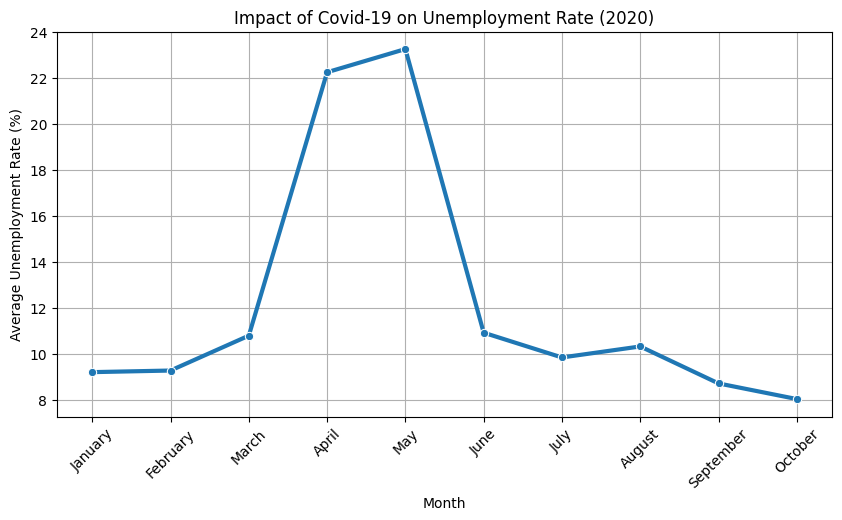

In [55]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_covid.index,
    y=monthly_covid.values,
    marker="o",
    linewidth=3
)

plt.title("Impact of Covid-19 on Unemployment Rate (2020)")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)

plt.grid(True)

plt.show()

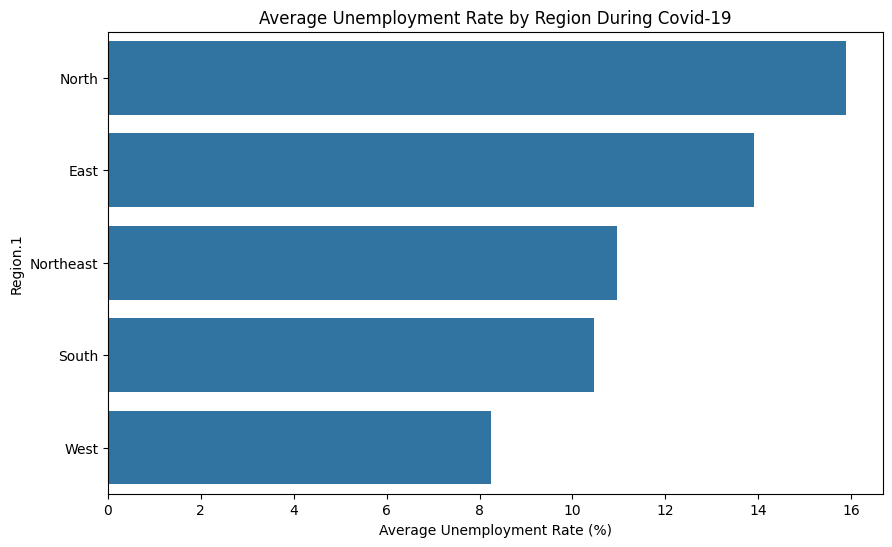

In [56]:
plt.figure(figsize=(10,6))

region_avg = covid_df.groupby("Region.1")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

sns.barplot(
    x=region_avg.values,
    y=region_avg.index
)

plt.title("Average Unemployment Rate by Region During Covid-19")

plt.xlabel("Average Unemployment Rate (%)")

plt.show()

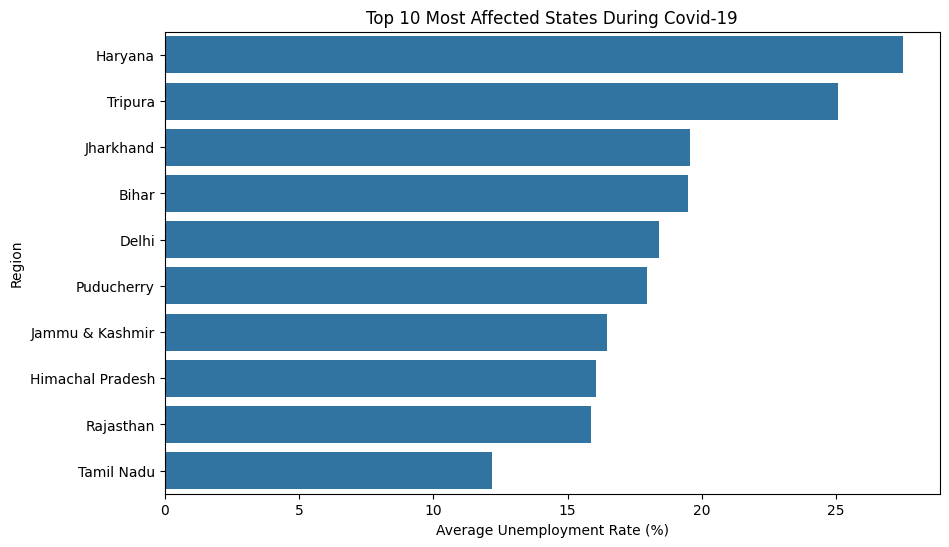

In [57]:
#HIGHEST IMPACT STATES DURING COVID:
top10 = covid_df.groupby("Region")["Estimated Unemployment Rate (%)"]\
                .mean()\
                .sort_values(ascending=False)\
                .head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 Most Affected States During Covid-19")

plt.xlabel("Average Unemployment Rate (%)")

plt.show()

# ***Covid-19 Insights***

- Unemployment increased sharply during the lockdown period, especially in April and May 2020.
- Some states experienced much higher unemployment than others, indicating unequal economic impact.
- Regional analysis shows that the pandemic affected all regions, but the severity varied.
- The findings highlight how Covid-19 disrupted employment across India.

#***Covid-19 Conclusion***

The Covid-19 pandemic had a significant impact on employment across India. The unemployment rate increased considerably during the lockdown months, particularly in April and May 2020. Although recovery began in the following months, the data clearly shows that the pandemic caused major disruptions in the labour market. Such analysis can help governments and policymakers design better employment support programs during future crises.